In [1]:
import os

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

seed = 888
data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
author = 'Tahoe100M'

In [3]:
files = os.listdir(os.path.join(data_path, 'processed'))
files = [f for f in files if f.endswith('_associations.csv') and f.startswith(author)]

r2_df_all = []
for f in files:
    if 'pls' in f:
        latent_space = 'pls'
        processing_type = f.split(author + '_')[1].split('_' + '_'.join([latent_space, latent_space, 'associations.csv']))[0]
    elif 'pca' in f:
        latent_space = 'pca'
        processing_type = f.split(author + '_')[1].split('_' + '_'.join([latent_space, latent_space[:-1], 'associations.csv']))[0]
        
    if processing_type.endswith('_activity') and not processing_type.startswith('TF'):
        processing_type = processing_type.split('_activity')[0]
    
    r2_df = pd.read_csv(os.path.join(data_path, 'processed', f), index_col = 0)
    r2_df['latent_space'] = latent_space
    r2_df['processing_type'] = processing_type
    
    r2_df.rename(columns = {r2_df.columns[0]: 'latent_component'}, inplace = True)
    
    r2_df_all.append(r2_df)
    
r2_df = pd.concat(r2_df_all, ignore_index=True)  

covariates = ['drug', 'cell_line', 'pcnt_mito', 'plate', 'phase', 'G2M_score', 'S_score'] 


In [4]:
def visualize_covariate(model_type, latent_space):
    viz_df = r2_df[(r2_df.model_type == model_type) & (r2_df.latent_space == latent_space)].copy()

    viz_df = pd.melt(viz_df.drop(columns = ['latent_component', 'latent_space', 'model_type']), 
            id_vars = ['processing_type'], 
            var_name = 'covariate', 
            value_name = 'var_explained'
           )

    fig, axes = plt.subplots(ncols = 4, nrows = 2, figsize = (20, 10))
    ax = axes.flatten()
    for (i, covariate) in enumerate(covariates):
        viz_df_ = viz_df[viz_df.covariate == covariate].drop(columns = 'covariate')
        ranked_pt = viz_df_.groupby(['processing_type']).median().sort_values(by = 'var_explained', ascending = False).index.tolist()

        viz_df_.processing_type = pd.Categorical(viz_df_.processing_type, 
                                     categories = ranked_pt, 
                                     ordered=True)
        sns.boxplot(data = viz_df_, x = 'processing_type', y = 'var_explained', ax = ax[i])
        ax[i].set_ylabel('Fraction of Variance Explained')
        ax[i].set_xlabel('Processing Type')
        for label in ax[i].get_xticklabels():
            label.set_rotation(45)
        ax[i].set_title(covariate)

    fig.suptitle('Latent Space: ' + latent_space.upper() + ' | ' + 'Relationship: ' + model_type.capitalize())
    fig.tight_layout()
    ;

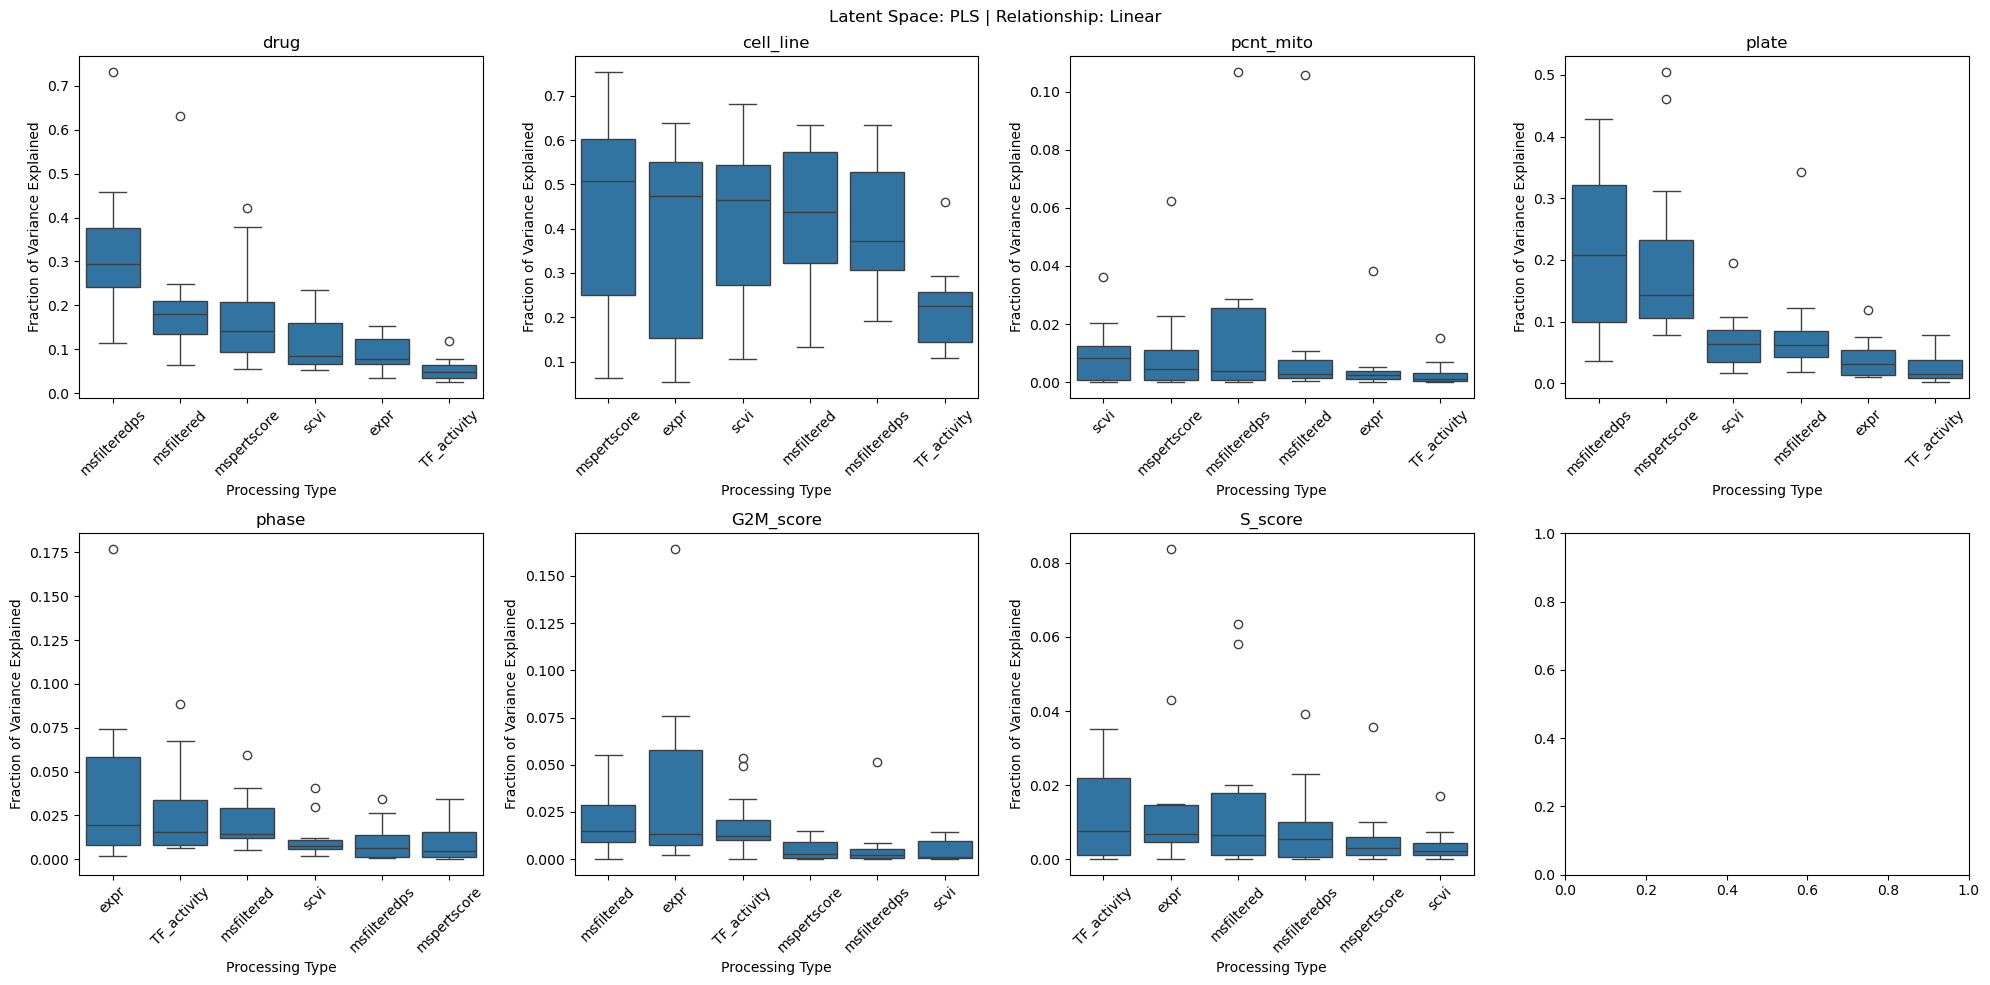

In [5]:
visualize_covariate(model_type = 'linear', latent_space = 'pls')

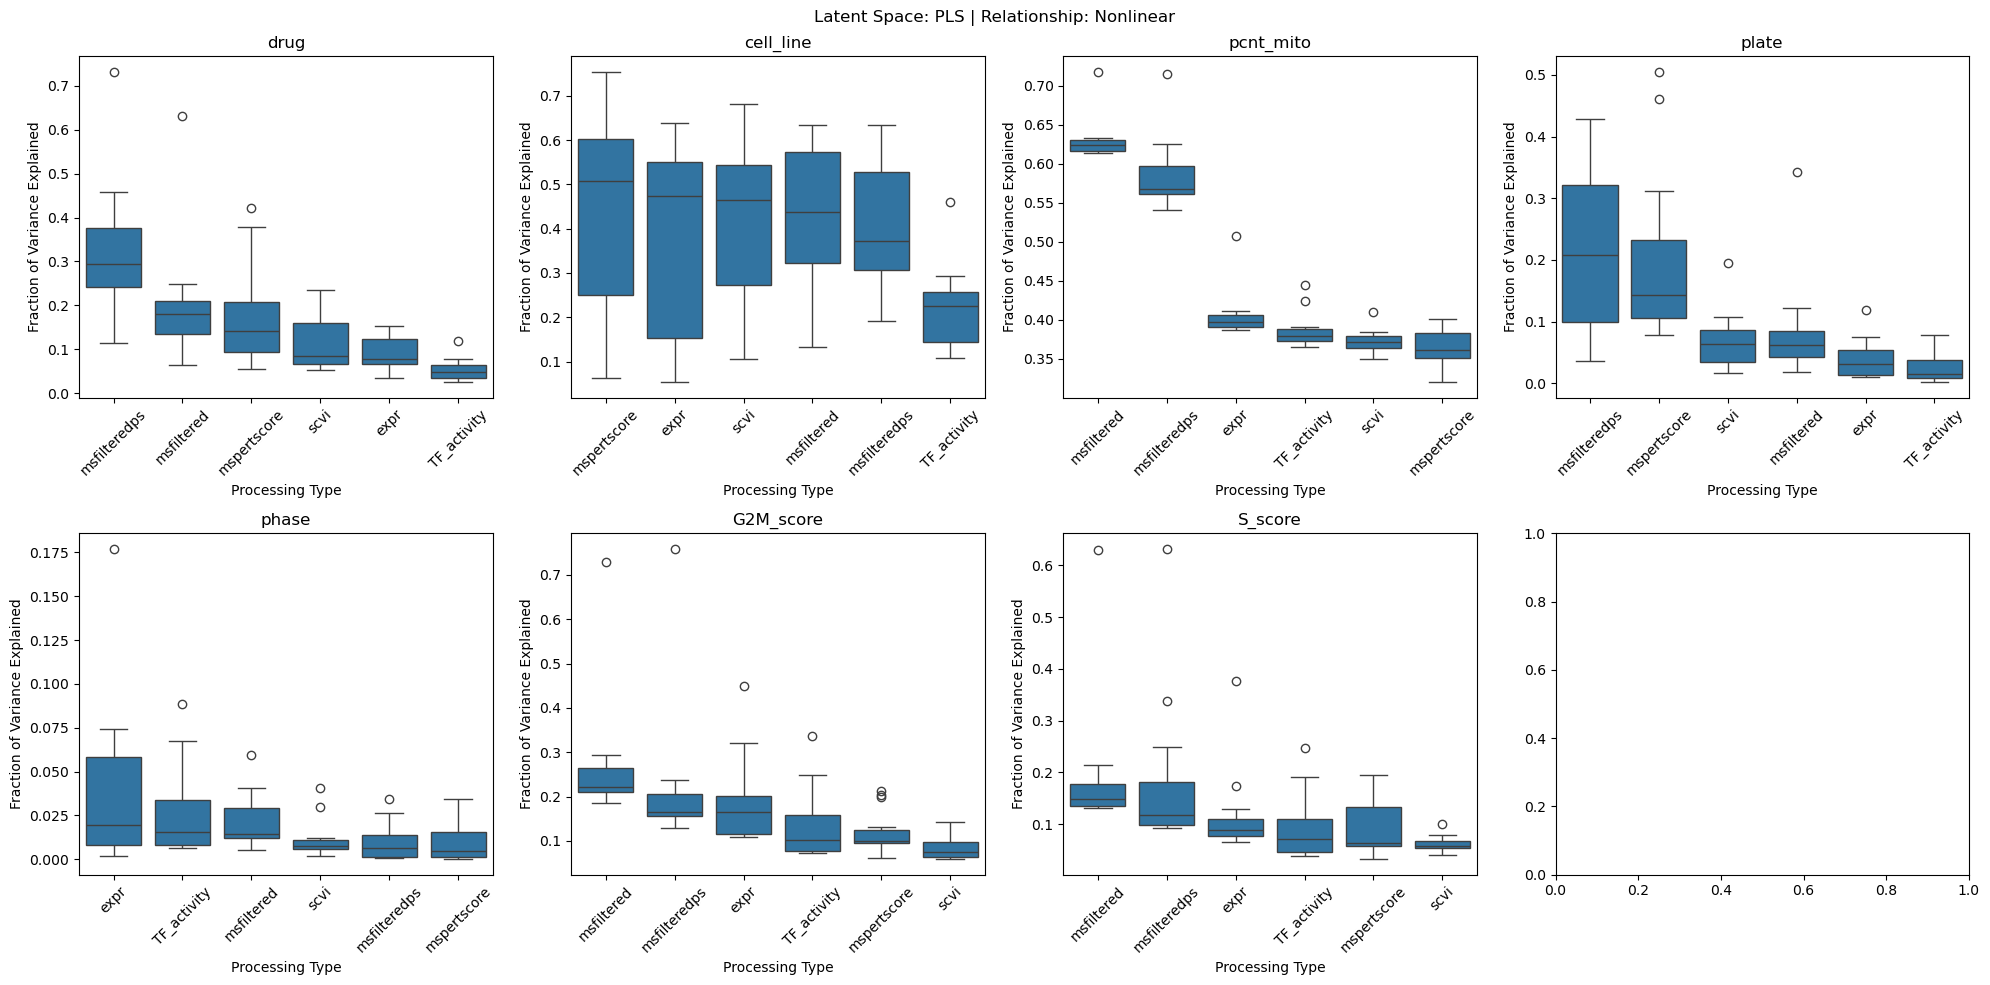

In [6]:
visualize_covariate(model_type = 'nonlinear', latent_space = 'pls')

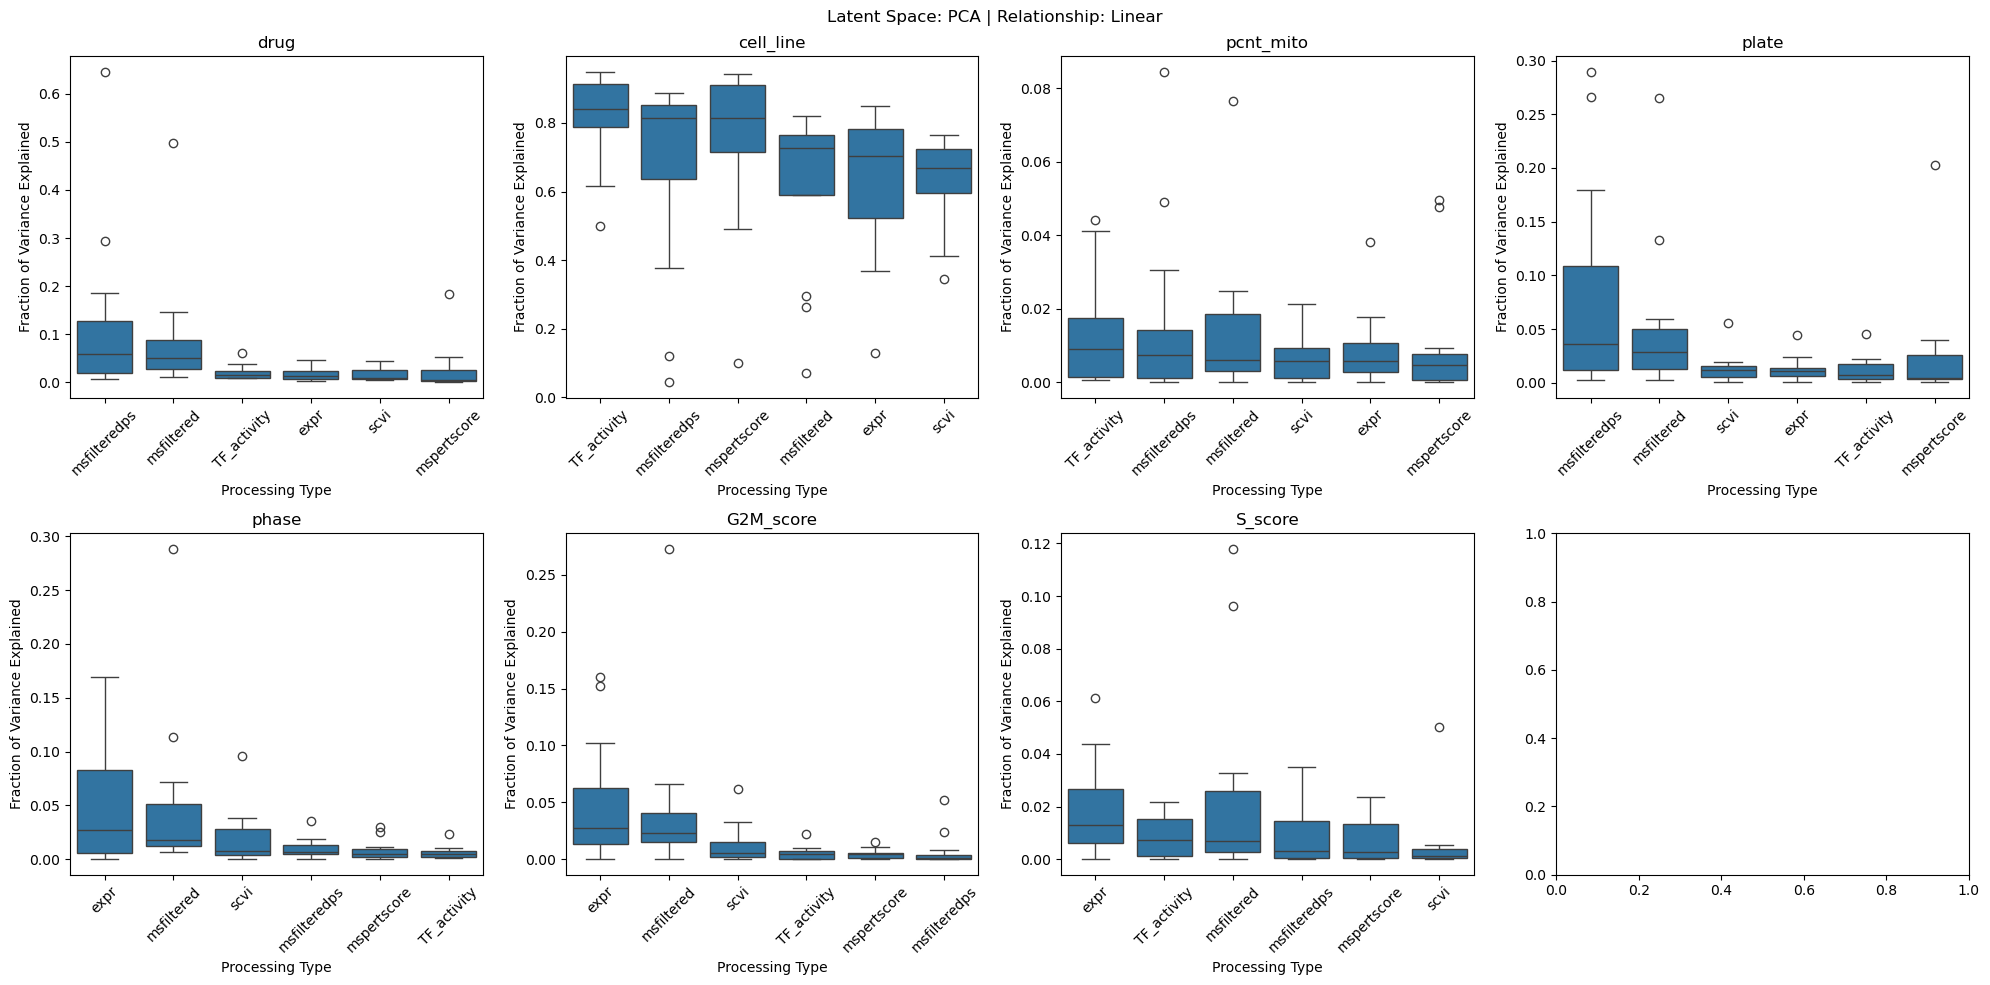

In [7]:
visualize_covariate(model_type = 'linear', latent_space = 'pca')

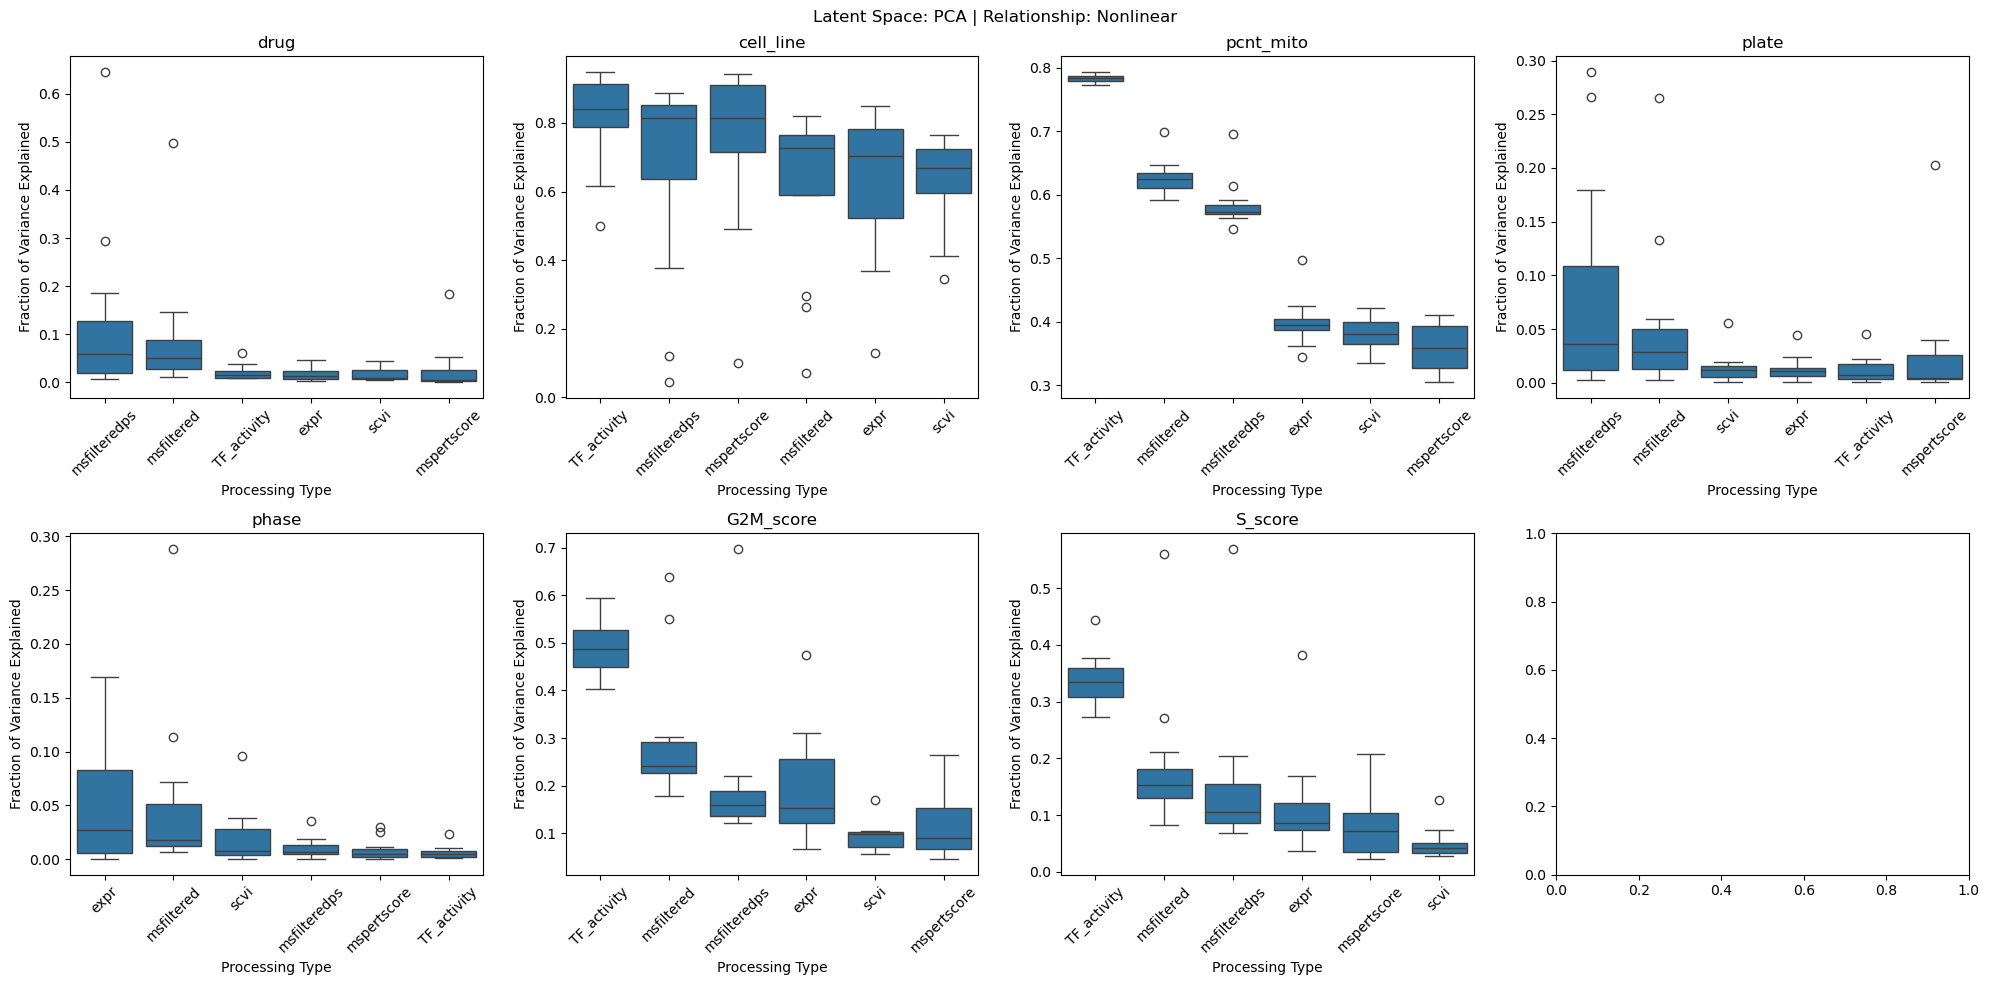

In [8]:
visualize_covariate(model_type = 'nonlinear', latent_space = 'pca')